In [1]:
import numpy as np

X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])


In [2]:
x_mean = np.sum(X) / len(X)
y_mean = np.sum(y) / len(y)

print("x̄ =", x_mean)
print("ȳ =", y_mean)

x̄ = 3.0
ȳ = 4.0


In [3]:
cov = np.sum((X - x_mean) * (y - y_mean)) / len(X)
print("Cov(X,Y) =", cov)


Cov(X,Y) = 1.2


In [4]:
var = np.sum((X - x_mean) ** 2) / len(X)
print("Var(X) =", var)

Var(X) = 2.0


In [5]:
m = cov / var
print("Slope (m) =", m)


Slope (m) = 0.6


In [6]:
c = y_mean - m * x_mean
print("Intercept (c) =", c)


Intercept (c) = 2.2


In [7]:
y_pred = m * X + c
print("Predictions:", y_pred)

Predictions: [2.8 3.4 4.  4.6 5.2]


In [8]:
errors = y - y_pred
print("Errors:", errors)

Errors: [-0.8  0.6  1.  -0.6 -0.2]


In [9]:
squared_errors = errors ** 2
print("Squared errors:", squared_errors)
print("SSE:", np.sum(squared_errors))

Squared errors: [0.64 0.36 1.   0.36 0.04]
SSE: 2.3999999999999995


### Altogether in a function

In [10]:
import numpy as np
# together in a function


def train_linear_regression(x, y):
    # Step 1: Calculate Means
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    # Step 2: Calculate Deviations
    # (Using numpy vectorization instead of a manual loop for efficiency)
    numerator = np.sum((x - mean_x) * (y - mean_y))
    denominator = np.sum((x - mean_x) ** 2)

    # Step 3: Calculate Slope (m)
    m = numerator / denominator

    # Step 4: Calculate Intercept (c)
    c = mean_y - (m * mean_x)

    return m, c

# Example Usage
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

m, c = train_linear_regression(x, y)
print(f"Slope (m): {m}")
print(f"Intercept (c): {c}")

# Step 5: Prediction
new_x = 6
prediction = m * new_x + c
print(f"Prediction for x={new_x}: {prediction}")

Slope (m): 0.6
Intercept (c): 2.2
Prediction for x=6: 5.8


ValueError: x and y must be the same size

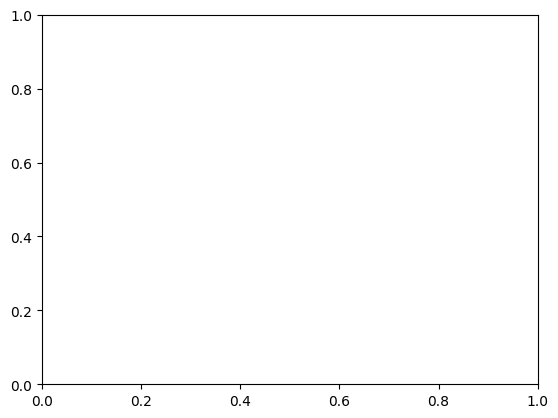

In [32]:
import matplotlib.pyplot as plt

# for linear model
X_linear = np.linspace(-10, 10, 200)
y_linear = m * X_linear + c

plt.scatter(X, y)
plt.plot(X_linear, y_linear, color='red')
plt.show()

In [12]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)  # sklearn expects 2D input
y = np.array([2, 4, 5, 4, 5])
print(X.shape)
# Create and train the model
model = LinearRegression()
model.fit(X, y)

# Get coefficients
m = model.coef_[0]  # slope
c = model.intercept_  # intercept
print(f"Slope (m): {m}")
print(f"Intercept (c): {c}")

# Test prediction
X_test = np.array([6, 7]).reshape(-1, 1)
y_pred = model.predict(X_test)
print(f"Predictions for {X_test.ravel()}: {y_pred}")

(5, 1)
Slope (m): 0.6
Intercept (c): 2.2
Predictions for [6 7]: [5.8 6.4]


In [13]:
X2 = np.array([
    [1,2],
    [4,3],
    [2,56],
    [5,9],
    [22,12]
])
X2.shape

y = np.array([2, 4, 5, 4, 5])
print(X.shape)
# Create and train the model
model = LinearRegression()
model.fit(X2, y)

# Get coefficients
m = model.coef_[0]  # slope
c = model.intercept_  # intercept
print(f"Slope (m): {m}")
print(f"Intercept (c): {c}")

# Test prediction
X_test = np.array([[6, 7]])
y_pred = model.predict(X_test)
print(f"Predictions for {X_test.ravel()}: {y_pred}")

(5, 1)
Slope (m): 0.08876934696805755
Intercept (c): 2.791162842456428
Predictions for [6 7]: [3.58209839]


### Now with open-form, training with gradient descent

In [14]:
import numpy as np

X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

m = 0.0   # bad initial guess
c = 0.0

lr = 0.01
epochs = 1000
n = len(X)


In [15]:
m = 0.0   # bad initial guess
c = 0.0

lr = 0.01
epochs = 1000
n = len(X)

for epoch in range(epochs):
    y_pred = m * X + c
    error = y - y_pred

    dm = (-2 / n) * np.sum(X * error)
    dc = (-2 / n) * np.sum(error)

    m -= lr * dm
    c -= lr * dc

    if epoch % 100 == 0:
        loss = np.mean(error ** 2)
        print(f"Epoch {epoch:4d} | Loss {loss:.4f} | m={m:.3f} c={c:.3f}")


Epoch    0 | Loss 17.2000 | m=0.264 c=0.080
Epoch  100 | Loss 0.8099 | m=0.972 c=0.858
Epoch  200 | Loss 0.6476 | m=0.865 c=1.244
Epoch  300 | Loss 0.5651 | m=0.789 c=1.518
Epoch  400 | Loss 0.5232 | m=0.735 c=1.714
Epoch  500 | Loss 0.5020 | m=0.696 c=1.854
Epoch  600 | Loss 0.4912 | m=0.668 c=1.953
Epoch  700 | Loss 0.4857 | m=0.649 c=2.024
Epoch  800 | Loss 0.4829 | m=0.635 c=2.075
Epoch  900 | Loss 0.4815 | m=0.625 c=2.111


In [16]:
m_ols = np.sum((X - X.mean()) * (y - y.mean())) / np.sum((X - X.mean()) ** 2)
c_ols = y.mean() - m_ols * X.mean()

print("Gradient Descent:", m, c)
print("OLS Solution:    ", m_ols, c_ols)


Gradient Descent: 0.6176946148762643 2.136116825825789
OLS Solution:     0.6 2.2


### Multiple Linear Regression

In [17]:
from sklearn.datasets import fetch_california_housing
import numpy as np
import pandas as pd

# Load dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

# Pick 2 features for simplicity
X = df[['MedInc', 'AveRooms']].values
y = df['MedHouseVal'].values

n = X.shape[0]

# Compute means
x1_mean = X[:,0].mean()
x2_mean = X[:,1].mean()
y_mean = y.mean()

# Center the data
x1 = X[:,0] - x1_mean
x2 = X[:,1] - x2_mean
y_centered = y - y_mean

In [18]:
# compute variance and covariance
Var_x1 = np.sum(x1**2) / n
Var_x2 = np.sum(x2**2) / n
Cov_x1x2 = np.sum(x1*x2) / n
Cov_x1y  = np.sum(x1*y_centered) / n
Cov_x2y  = np.sum(x2*y_centered) / n

In [19]:
# Solve w2 first
w2 = (Cov_x2y - (Cov_x1y * Cov_x1x2 / Var_x1)) / (Var_x2 - (Cov_x1x2**2 / Var_x1))

# Solve w1
w1 = (Cov_x1y - w2 * Cov_x1x2) / Var_x1

# Compute intercept
b = y_mean - w1*x1_mean - w2*x2_mean

print("Scratch MLR:")
print("w1 (MedInc):", w1)
print("w2 (AveRooms):", w2)
print("Intercept:", b)

Scratch MLR:
w1 (MedInc): 0.4341630185374788
w2 (AveRooms): -0.03811061354501983
Intercept: 0.5949584738121938


In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("\nSklearn LinearRegression:")
print("w1 (MedInc):", model.coef_[0])
print("w2 (AveRooms):", model.coef_[1])
print("Intercept:", model.intercept_)


Sklearn LinearRegression:
w1 (MedInc): 0.4341630185374793
w2 (AveRooms): -0.03811061354501974
Intercept: 0.5949584738121916


### Using all features with Multiple Linear Regressionn

In [21]:
from sklearn.linear_model import LinearRegression

X = df.values[:, :-1]  # all 8 features
y = df.values[:, -1]

model = LinearRegression()
model.fit(X, y)

print("\nSklearn LinearRegression (all features):")
print("Intercept:", model.intercept_)
print("Weights:", model.coef_)


Sklearn LinearRegression (all features):
Intercept: -36.94192020718454
Weights: [ 4.36693293e-01  9.43577803e-03 -1.07322041e-01  6.45065694e-01
 -3.97638942e-06 -3.78654265e-03 -4.21314378e-01 -4.34513755e-01]


### Why Polynomial Regression?

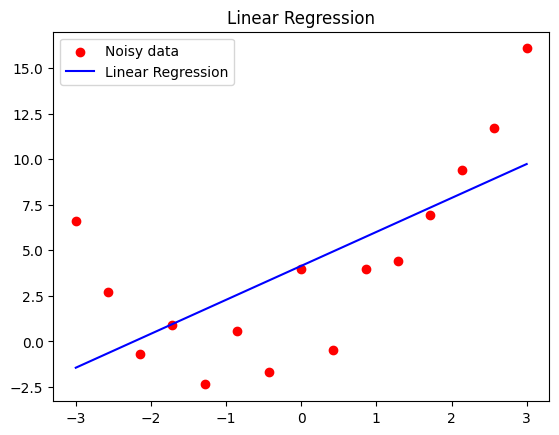

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Create non-linear data (quadratic)
x = np.linspace(-3, 3, 15)
y = x**2 + 2*x + 1  # True quadratic curve
y_noisy = y + np.random.randn(*y.shape) * 2  # Add small noise

X_lin = np.c_[np.ones(x.shape[0]), x]  # add bias column
w_lin = np.linalg.inv(X_lin.T @ X_lin) @ X_lin.T @ y_noisy
y_lin_pred = X_lin @ w_lin

plt.scatter(x, y_noisy, color='red', label='Noisy data')
plt.plot(x, y_lin_pred, color='blue', label='Linear Regression')
# plt.plot(x, y_poly_pred, color='green', label='Polynomial Regression')
plt.legend()
plt.title("Linear Regression")
plt.show()

### Polynomial Regression

Polynomial weights: [1.00000000e+00 7.28306304e-14 1.00000000e+00]


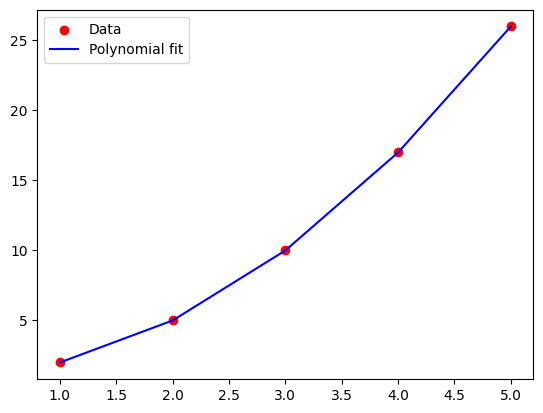

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 5, 10, 17, 26])  # roughly y = x^2 + 1

# Degree of polynomial
degree = 2

# Create polynomial features: [1, x, x^2]
X_poly = np.ones((x.shape[0], 1))
for d in range(1, degree + 1):
    X_poly = np.c_[X_poly, x**d]

# Compute weights using normal equation: w = (X^T X)^-1 X^T y
w_poly = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ y

# Predict
y_pred = X_poly @ w_poly

print("Polynomial weights:", w_poly)

# Plot
plt.scatter(x, y, color='red', label='Data')
plt.plot(x, y_pred, color='blue', label='Polynomial fit')
plt.legend()
plt.show()

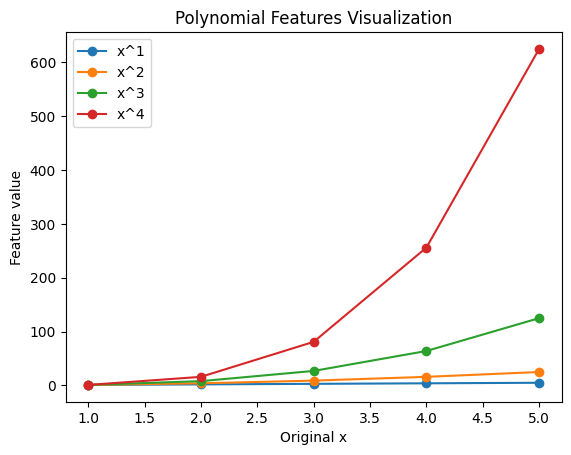

In [24]:
import matplotlib.pyplot as plt

degree = 4

# Create polynomial features: [1, x, x^2]
X_poly = np.ones((x.shape[0], 1))
for d in range(1, degree + 1):
    X_poly = np.c_[X_poly, x**d]


for i in range(1, X_poly.shape[1]):  # skip bias column
    plt.plot(x, X_poly[:, i], marker='o', label=f'x^{i}')
plt.xlabel("Original x")
plt.ylabel("Feature value")
plt.legend()
plt.title("Polynomial Features Visualization")
plt.show()

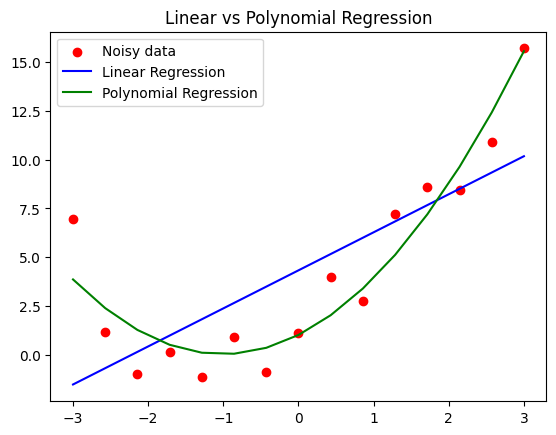

In [25]:
# going back to previous question
import numpy as np
import matplotlib.pyplot as plt

# Create non-linear data (quadratic)
x = np.linspace(-3, 3, 15)
y = x**2 + 2*x + 1  # True quadratic curve
y_noisy = y + np.random.randn(*y.shape) * 2  # Add small noise

# ---- 1. Linear Regression on this data ----
X_lin = np.c_[np.ones(x.shape[0]), x]  # add bias column
w_lin = np.linalg.inv(X_lin.T @ X_lin) @ X_lin.T @ y_noisy
y_lin_pred = X_lin @ w_lin

# ---- 2. Polynomial Regression (degree 2) ----
degree = 2
X_poly = np.ones((x.shape[0], 1))
for d in range(1, degree+1):
    X_poly = np.c_[X_poly, x**d]

w_poly = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ y_noisy
y_poly_pred = X_poly @ w_poly

# ---- Plot ----
plt.scatter(x, y_noisy, color='red', label='Noisy data')
plt.plot(x, y_lin_pred, color='blue', label='Linear Regression')
plt.plot(x, y_poly_pred, color='green', label='Polynomial Regression')
plt.legend()
plt.title("Linear vs Polynomial Regression")
plt.show()

Polynomial feature matrix X_poly:
 [[ 1.         -3.          9.        ]
 [ 1.         -2.57142857  6.6122449 ]
 [ 1.         -2.14285714  4.59183673]
 [ 1.         -1.71428571  2.93877551]
 [ 1.         -1.28571429  1.65306122]
 [ 1.         -0.85714286  0.73469388]
 [ 1.         -0.42857143  0.18367347]
 [ 1.          0.          0.        ]
 [ 1.          0.42857143  0.18367347]
 [ 1.          0.85714286  0.73469388]
 [ 1.          1.28571429  1.65306122]
 [ 1.          1.71428571  2.93877551]
 [ 1.          2.14285714  4.59183673]
 [ 1.          2.57142857  6.6122449 ]
 [ 1.          3.          9.        ]]
Polynomial weights: [1.0575629  1.83009914 0.85464948]


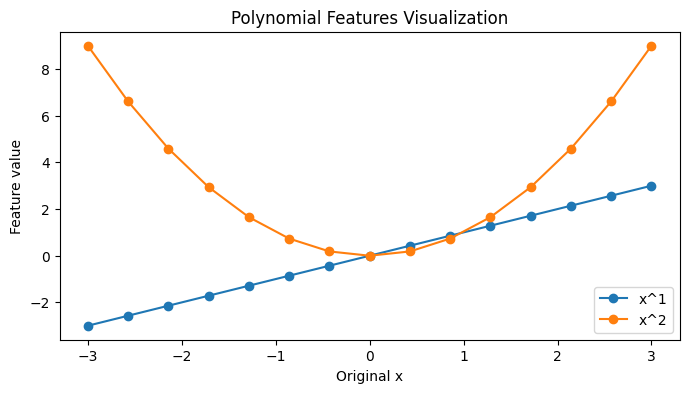

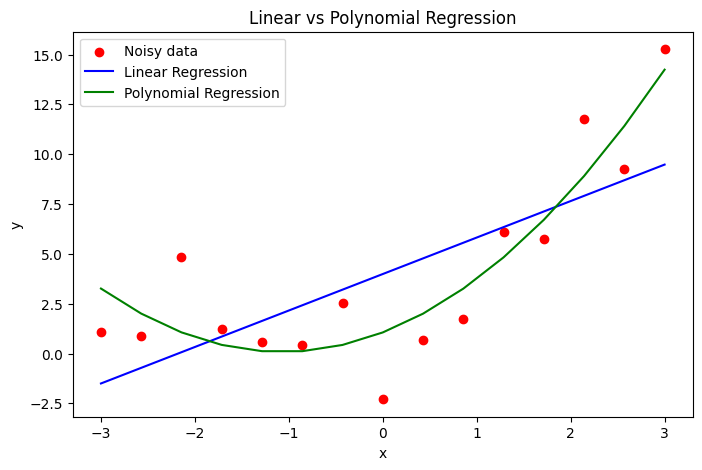

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Non-linear quadratic data
x = np.linspace(-3, 3, 15)
y = x**2 + 2*x + 1
y_noisy = y + np.random.randn(*y.shape) * 2

# 2. Simple Linear Regression function
def linear_regression(X, y):
    """Compute weights using normal equation."""
    return np.linalg.inv(X.T @ X) @ X.T @ y

# 3. Linear Regression on original x
X_lin = np.c_[np.ones(x.shape[0]), x]  # bias + x
w_lin = linear_regression(X_lin, y_noisy)
y_lin_pred = X_lin @ w_lin

# 4. Polynomial Regression (degree 2)
degree = 2
X_poly = np.ones((x.shape[0], 1))  # start with bias
for d in range(1, degree + 1):
    X_poly = np.c_[X_poly, x**d]

# Show polynomial feature matrix
print("Polynomial feature matrix X_poly:\n", X_poly)

# Solve using linear regression function
w_poly = linear_regression(X_poly, y_noisy)
y_poly_pred = X_poly @ w_poly

print("Polynomial weights:", w_poly)

# 5. Visualize polynomial features
plt.figure(figsize=(8,4))
for i in range(1, X_poly.shape[1]):  # skip bias
    plt.plot(x, X_poly[:, i], marker='o', label=f'x^{i}')
plt.xlabel("Original x")
plt.ylabel("Feature value")
plt.title("Polynomial Features Visualization")
plt.legend()
plt.show()

# 6. Plot regression results
plt.figure(figsize=(8,5))
plt.scatter(x, y_noisy, color='red', label='Noisy data')
plt.plot(x, y_lin_pred, color='blue', label='Linear Regression')
plt.plot(x, y_poly_pred, color='green', label='Polynomial Regression')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()

## Classification

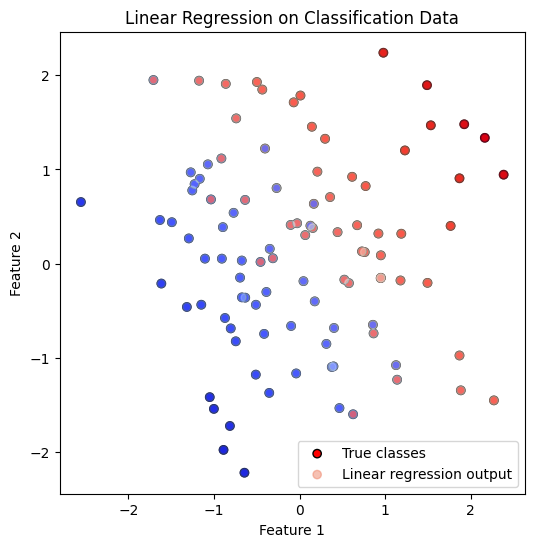

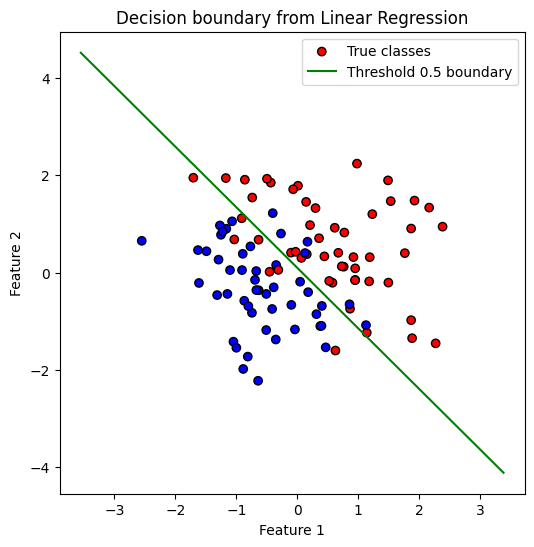

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(0)
X = np.random.randn(100, 2)
y = (X[:,0] + X[:,1] + 0.5*np.random.randn(X.shape[0]) > 0).astype(int)

lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_lin_pred = lin_reg.predict(X)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k', label='True classes')
# Plot predicted color intensity based on regression output
plt.scatter(X[:,0], X[:,1], c=y_lin_pred, cmap='coolwarm', alpha=0.5, label='Linear regression output')
plt.title("Linear Regression on Classification Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# Linear regression line: w0 + w1*x1 + w2*x2 = 0.5
w0, w1 = lin_reg.intercept_, lin_reg.coef_[0]
w2 = lin_reg.coef_[1]

x_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
y_vals = (0.5 - w0 - w1*x_vals)/w2  # threshold 0.5 to decide class
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k', label='True classes')
plt.plot(x_vals, y_vals, color='green', label='Threshold 0.5 boundary')
plt.title("Decision boundary from Linear Regression")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

### Sigmoid Function

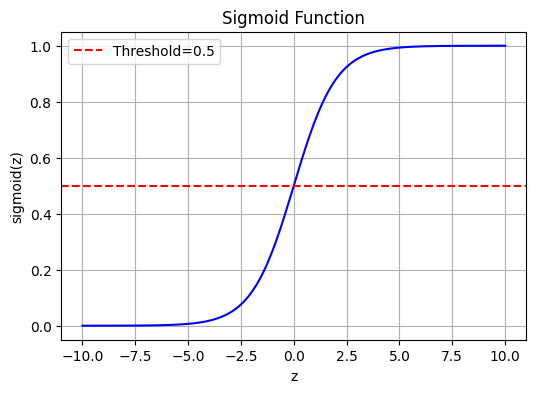

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Values to plot
z = np.linspace(-10, 10, 200)
y = sigmoid(z)

plt.figure(figsize=(6,4))
plt.plot(z, y, color='blue')
plt.axhline(0.5, color='red', linestyle='--', label='Threshold=0.5')
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.grid(True)
plt.legend()
plt.show()

### Logistic Regression from scratch

Learned weights: [-0.04314127  6.93641289  6.67031457]
Training accuracy: 1.0


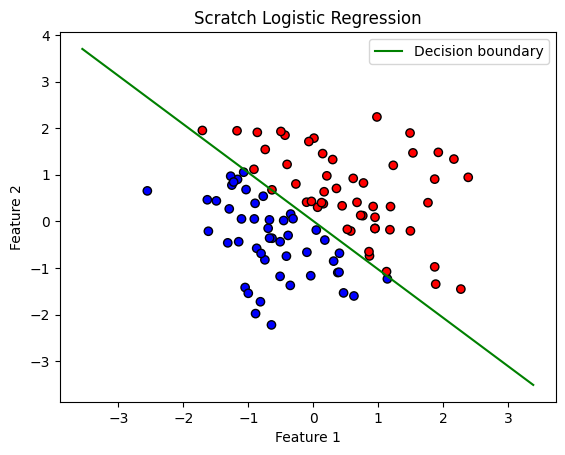

In [29]:
import numpy as np

np.random.seed(0)
X = np.random.randn(100, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)  # simple linearly separable

X_b = np.c_[np.ones(X.shape[0]), X]  # add bias column

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_regression(X, y, lr=0.1, epochs=5000):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)

    for _ in range(epochs):
        z = X @ w
        y_hat = sigmoid(z)
        # Gradient
        # gradient of loss function with respect to weight
        # loss function is binary cross entropy
        gradient = (1/n_samples) * X.T @ (y_hat - y)
        # Update weights
        w -= lr * gradient
    return w

# Train model
w = logistic_regression(X_b, y)
print("Learned weights:", w)

# Predictions
y_pred_prob = sigmoid(X_b @ w)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Accuracy
accuracy = np.mean(y_pred == y)
print("Training accuracy:", accuracy)

plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k')
x_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
y_vals = -(w[0] + w[1]*x_vals)/w[2]  # line: w0 + w1*x + w2*y = 0
plt.plot(x_vals, y_vals, color='green', label='Decision boundary')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scratch Logistic Regression")
plt.legend()
plt.show()

In [30]:
# using sklearn library
clf = LogisticRegression()
clf.fit(X, y)

# Predictions
y_pred = clf.predict(X)
y_prob = clf.predict_proba(X)[:, 1]

# Accuracy
accuracy = np.mean(y_pred == y)
print("Training accuracy:", accuracy)
print("Weights:", clf.coef_, "Bias:", clf.intercept_)

# decision boundary
x_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
w0, w1 = clf.coef_[0]
b = clf.intercept_[0]
y_vals = -(b + w0*x_vals)/w1

plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k', label='True classes')
plt.plot(x_vals, y_vals, color='green', label='Decision boundary')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression (sklearn)")
plt.legend()
plt.show()

NameError: name 'LogisticRegression' is not defined

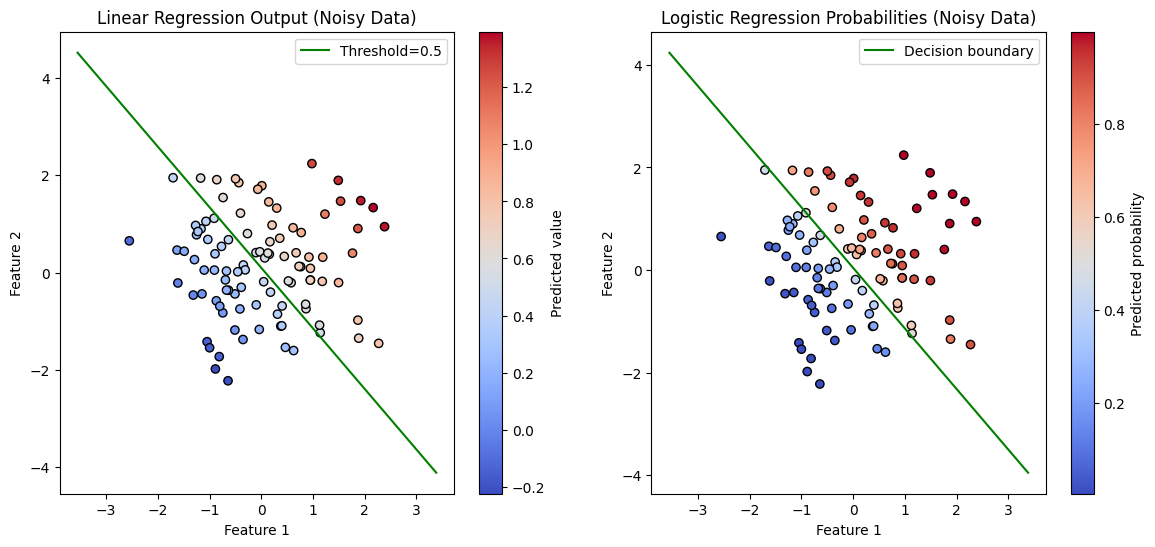

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

# ---- Noisy 2D data ----
np.random.seed(0)
X = np.random.randn(100, 2)
y = (X[:,0] + X[:,1] + 0.5*np.random.randn(X.shape[0]) > 0).astype(int)

# ---- 1. Linear Regression ----
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_lin_pred = lin_reg.predict(X)

w0, w1 = lin_reg.coef_
b0 = lin_reg.intercept_
x_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
y_lin_vals = (0.5 - b0 - w0*x_vals)/w1  # threshold 0.5

# ---- 2. Logistic Regression ----
log_reg = LogisticRegression()
log_reg.fit(X, y)
y_prob = log_reg.predict_proba(X)[:,1]
y_pred = log_reg.predict(X)

w0_l, w1_l = log_reg.coef_[0]
b_l = log_reg.intercept_[0]
y_log_vals = -(b_l + w0_l*x_vals)/w1_l

# ---- 3. Plot comparison ----
plt.figure(figsize=(14,6))

# ---- Linear Regression ----
plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], c=y_lin_pred, cmap='coolwarm', edgecolors='k')
plt.plot(x_vals, y_lin_vals, color='green', label='Threshold=0.5')
plt.title("Linear Regression Output (Noisy Data)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Predicted value")
plt.legend()

# ---- Logistic Regression ----
plt.subplot(1,2,2)
plt.scatter(X[:,0], X[:,1], c=y_prob, cmap='coolwarm', edgecolors='k')
plt.plot(x_vals, y_log_vals, color='green', label='Decision boundary')
plt.title("Logistic Regression Probabilities (Noisy Data)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Predicted probability")
plt.legend()

plt.show()

### Multi-class classification

/tmp/ipython-input-58991570.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='pastel')


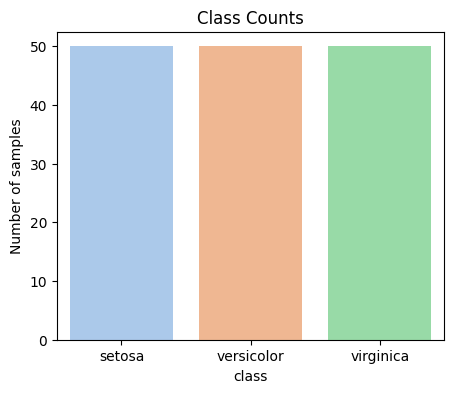

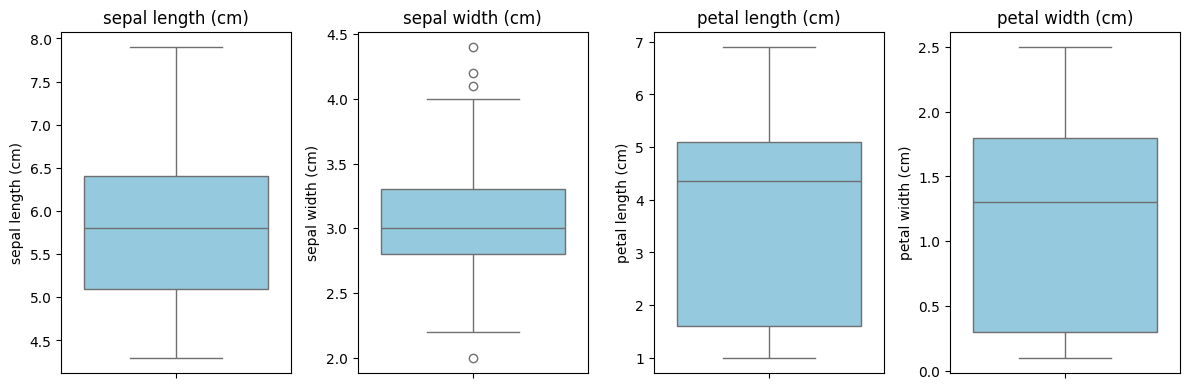

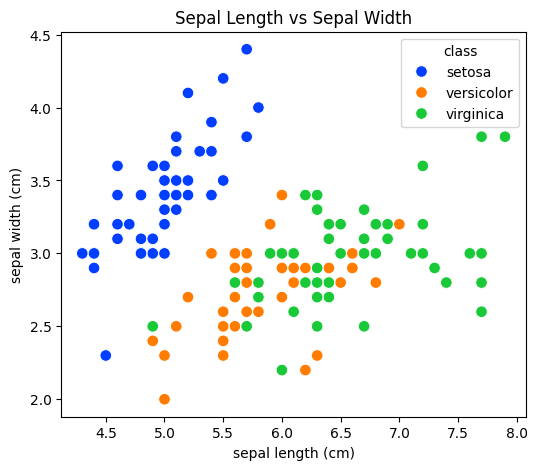

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.35   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  target  
count            150.00  150.00  
mean               1.20    1.00  
std                0.76    0.82  
min                0.10    0.00  
25%                0.30    0.00  
50%                1.30    1.00  
75%                1.80    2.00  
max                2.50    2.00  
class
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# Convert to DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['class'] = df['target'].apply(lambda i: class_names[i])

# 1. Count of each class
plt.figure(figsize=(5,4))
sns.countplot(x='class', data=df, palette='pastel')
plt.title("Class Counts")
plt.ylabel("Number of samples")
plt.show()

# 2. Boxplots for all features
plt.figure(figsize=(12,4))
for i, feature in enumerate(feature_names):
    plt.subplot(1,4,i+1)
    sns.boxplot(y=df[feature], color='skyblue')
    plt.title(feature)
plt.tight_layout()
plt.show()

# 3. Scatter plot of first 2 features
plt.figure(figsize=(6,5))
sns.scatterplot(x=feature_names[0], y=feature_names[1], hue='class', data=df, palette='bright', s=70)
plt.title("Sepal Length vs Sepal Width")
plt.show()

# 4. Feature summary as table (optional, for screenshot)
summary = df.describe().round(2)
print(summary)

# 5. Class count table (optional)
print(df['class'].value_counts())


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test Accuracy: 1.0


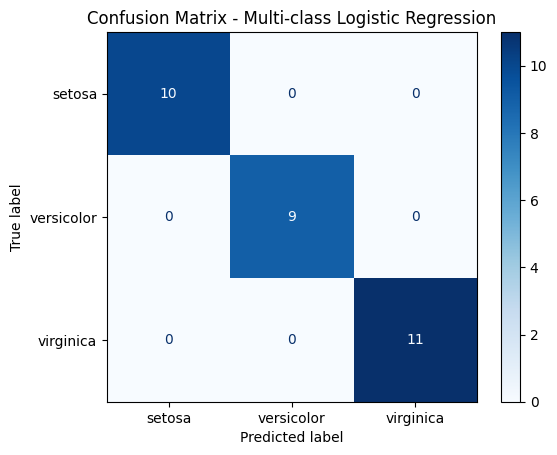

First 5 predicted probabilities:
[[3.80392750e-03 8.27739664e-01 1.68456409e-01]
 [9.46973015e-01 5.30267859e-02 1.98766047e-07]
 [8.86161500e-09 1.54855320e-03 9.98451438e-01]
 [6.48590621e-03 7.92228336e-01 2.01285757e-01]
 [1.45781656e-03 7.74128267e-01 2.24413916e-01]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

#  Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Fit logistic regression
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
clf.fit(X_train, y_train)

#  Predictions
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)

#  Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Multi-class Logistic Regression")
plt.show()

#  Show first 5 probabilities
print("First 5 predicted probabilities:")
print(y_prob[:5])


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


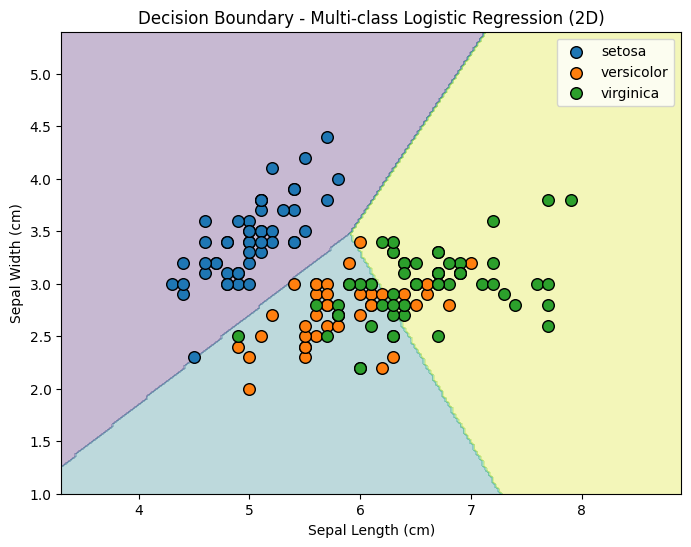

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Use only first 2 features for visualization
X_vis = X[:, :2]
y_vis = y

# Train logistic regression on 2D features
clf_vis = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
clf_vis.fit(X_vis, y_vis)

# Create a meshgrid for plotting decision regions
x_min, x_max = X_vis[:,0].min() - 1, X_vis[:,0].max() + 1
y_min, y_max = X_vis[:,1].min() - 1, X_vis[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict class for each point in the grid
Z = clf_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# Plot training points
for i, class_name in enumerate(class_names):
    plt.scatter(X_vis[y_vis==i, 0], X_vis[y_vis==i, 1], label=class_name, edgecolors='k', s=70)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Decision Boundary - Multi-class Logistic Regression (2D)")
plt.legend()
plt.show()


### Understanding softmax function

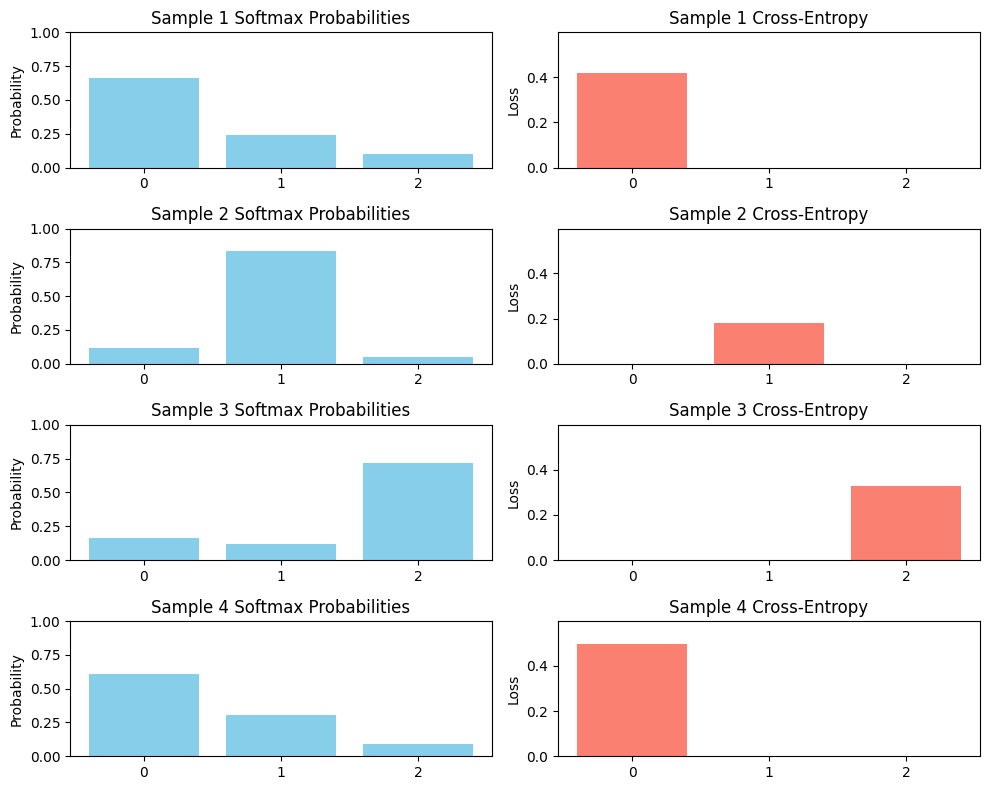

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sample logits for 4 samples and 3 classes
logits = np.array([
    [2.0, 1.0, 0.1],
    [1.0, 3.0, 0.2],
    [0.5, 0.2, 2.0],
    [2.2, 1.5, 0.3]
])

# True labels in one-hot encoding
y_true = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
    [1, 0, 0]
])

# Softmax function
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Cross-entropy per sample
def cross_entropy_per_sample(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-9), axis=1)

# Compute probabilities and losses
probs = softmax(logits)
losses = cross_entropy_per_sample(y_true, probs)

# Visualization
n_samples, n_classes = probs.shape
fig, axes = plt.subplots(n_samples, 2, figsize=(10, 8))

for i in range(n_samples):
    # Softmax probabilities
    axes[i,0].bar(range(n_classes), probs[i], color='skyblue')
    axes[i,0].set_ylim(0,1)
    axes[i,0].set_xticks(range(n_classes))
    axes[i,0].set_title(f"Sample {i+1} Softmax Probabilities")
    axes[i,0].set_ylabel("Probability")

    # Cross-entropy contribution
    axes[i,1].bar(range(n_classes), -y_true[i]*np.log(probs[i]+1e-9), color='salmon')
    axes[i,1].set_ylim(0, np.max(losses)+0.1)
    axes[i,1].set_xticks(range(n_classes))
    axes[i,1].set_title(f"Sample {i+1} Cross-Entropy")
    axes[i,1].set_ylabel("Loss")

plt.tight_layout()
plt.show()


### k-means clustering

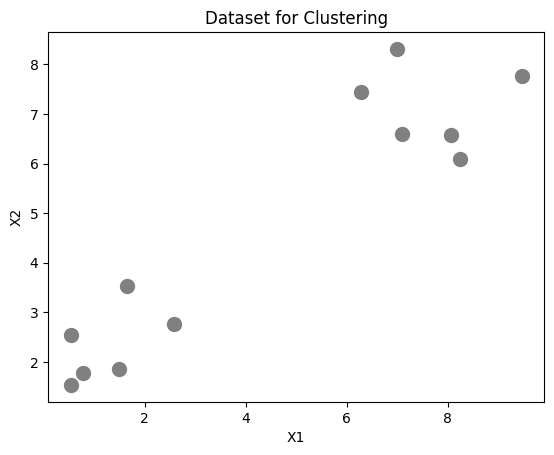

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 2D dataset (6 points per cluster)
np.random.seed(42)
cluster1 = np.random.randn(6,2) + np.array([1,2])
cluster2 = np.random.randn(6,2) + np.array([8,8])
X = np.vstack([cluster1, cluster2])

# Plot raw points
plt.scatter(X[:,0], X[:,1], s=100, color='gray')
plt.title("Dataset for Clustering")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

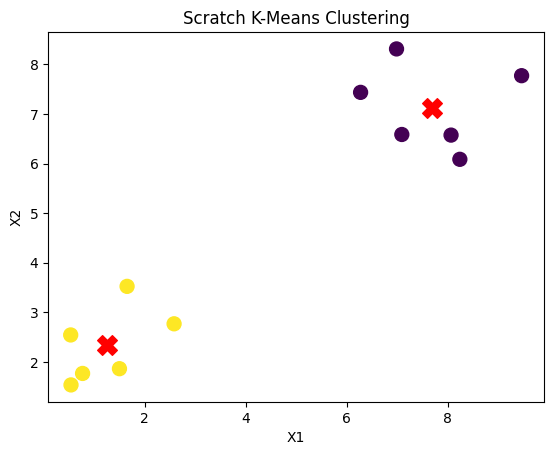

In [ ]:
K = 2
np.random.seed(42)
# Initialize centroids randomly
centroids = X[np.random.choice(range(X.shape[0]), K, replace=False)]

for iteration in range(10):
    # Assign points to nearest centroid
    distances = np.sqrt(((X[:, np.newaxis] - centroids[np.newaxis, :])**2).sum(axis=2))
    labels = np.argmin(distances, axis=1)

    # Update centroids
    new_centroids = np.array([X[labels==k].mean(axis=0) for k in range(K)])

    if np.allclose(centroids, new_centroids):
        break
    centroids = new_centroids

# Plot clusters and centroids
plt.scatter(X[:,0], X[:,1], c=labels, s=100, cmap='viridis')
plt.scatter(centroids[:,0], centroids[:,1], color='red', marker='X', s=200)
plt.title("Scratch K-Means Clustering")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()


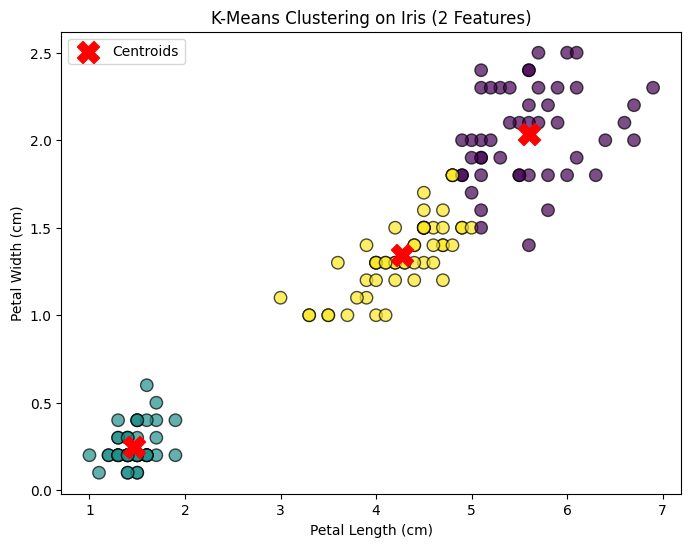

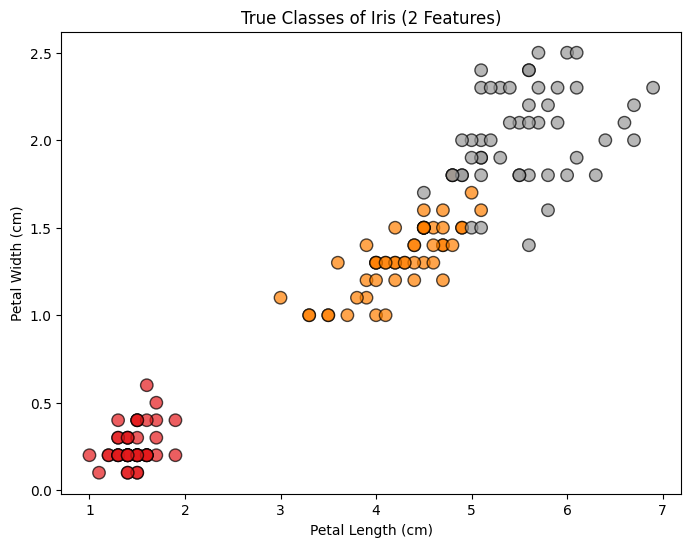

Cluster labels (first 20 samples): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Centroids:
 [[5.59583333 2.0375    ]
 [1.462      0.246     ]
 [4.26923077 1.34230769]]


In [ ]:
### K means with iris dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

# Load Iris dataset
iris = load_iris()
X = iris.data  # 4 features
y = iris.target  # true labels (for comparison)
feature_names = iris.feature_names

# Select 2 features for visualization
X_vis = X[:, [2, 3]]  # petal length & petal width

# Fit K-Means
K = 3
kmeans = KMeans(n_clusters=K, random_state=42)
kmeans.fit(X_vis)

labels = kmeans.labels_          # predicted cluster assignments
centroids = kmeans.cluster_centers_  # cluster centers

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(X_vis[:,0], X_vis[:,1], c=labels, cmap='viridis', s=80, alpha=0.7, edgecolors='k')
plt.scatter(centroids[:,0], centroids[:,1], color='red', marker='X', s=250, label='Centroids')
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("K-Means Clustering on Iris (2 Features)")
plt.legend()
plt.show()

# Compare with true labels
plt.figure(figsize=(8,6))
plt.scatter(X_vis[:,0], X_vis[:,1], c=y, cmap='Set1', s=80, alpha=0.7, edgecolors='k')
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("True Classes of Iris (2 Features)")
plt.show()

# Show predictions
print("Cluster labels (first 20 samples):", labels[:20])
print("Centroids:\n", centroids)


### Logistic Regression with Image Dataset

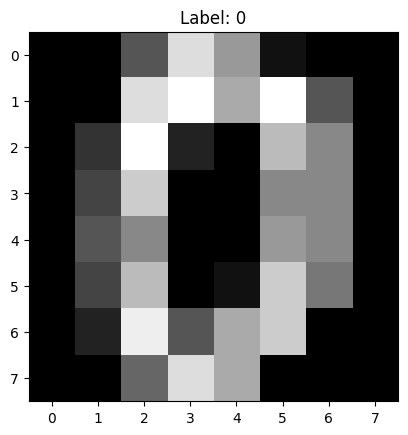

Original shape: (1797, 8, 8)
Flattened shape: (1797, 64)


In [ ]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np

# Load example digits dataset (8x8 images)
digits = load_digits()
X = digits.images  # shape (n_samples, 8, 8)
y = digits.target  # labels 0-9

# Flatten images: 8x8 -> 64 features
X_flat = X.reshape(X.shape[0], -1)

# Show a sample
plt.imshow(X[0], cmap='gray')
plt.title(f"Label: {y[0]}")
plt.show()

print("Original shape:", X.shape)
print("Flattened shape:", X_flat.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test Accuracy: 0.975


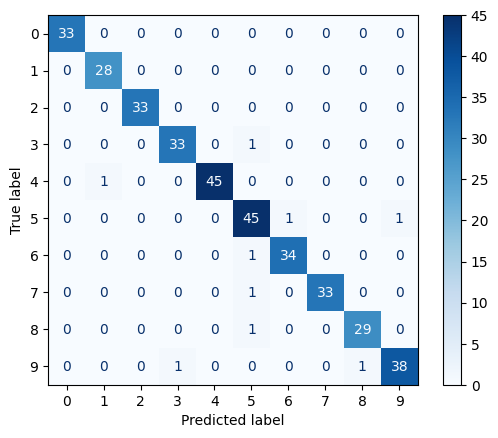

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42)

# Fit logistic regression (multi-class using 'multinomial')
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=digits.target_names)
disp.plot(cmap='Blues')
plt.show()